In [105]:
import os
import h5py
import numpy as np
import pandas as pd
from anndata.experimental import read_elem

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import matplotlib.colors as clr

In [2]:
workdir = '/data4/yyang117/orthrus2/Jamboree/'

#### Load in Data

In [32]:
def load_and_process(path, prefix, min_umi=500):
    out = {}

    with h5py.File(path, "r") as h5:
        out[f"{prefix}_modalities"] = list(h5["mod"].keys())

        out[f"{prefix}_gene_obs"] = read_elem(h5["mod/gene/obs"])
        out[f"{prefix}_gene_var"] = read_elem(h5["mod/gene/var"])
        out[f"{prefix}_gene_X"] = read_elem(h5["mod/gene/X"])

        out[f"{prefix}_guide_obs"] = read_elem(h5["mod/guide/obs"])
        out[f"{prefix}_guide_var"] = read_elem(h5["mod/guide/var"])
        out[f"{prefix}_guide_assignment"] = read_elem(h5["mod/guide/layers/guide_assignment"])

    gene_X = out[f"{prefix}_gene_X"]
    gene_var = out[f"{prefix}_gene_var"]
    guide_var = out[f"{prefix}_guide_var"]
    guide_assignment = out[f"{prefix}_guide_assignment"]

    mt = gene_var["mt"].fillna(False).astype(bool).values if "mt" in gene_var else np.zeros(gene_X.shape[1], bool)
    ribo = gene_var["ribo"].fillna(False).astype(bool).values if "ribo" in gene_var else np.zeros(gene_X.shape[1], bool)

    out[f"{prefix}_ribo_mt_mask"] = mt | ribo
    out[f"{prefix}_non_ribo_mt_mask"] = ~out[f"{prefix}_ribo_mt_mask"]

    gene_umi_all = np.asarray(gene_X.sum(axis=1)).ravel()
    gene_umi_ribo_mt = np.asarray(gene_X[:, out[f"{prefix}_ribo_mt_mask"]].sum(axis=1)).ravel()

    out[f"{prefix}_gene_umi_all"] = gene_umi_all
    out[f"{prefix}_gene_umi"] = gene_umi_all - gene_umi_ribo_mt
    out[f"{prefix}_mask"] = out[f"{prefix}_gene_umi"] >= min_umi

    guide_gene = guide_var["gene_name"]

    out[f"{prefix}_NTC_guides"] = guide_gene.isna().values
    out[f"{prefix}_OR_guides"] = guide_gene.str.contains(r"^OR", regex=True, case=False, na=False).values
    out[f"{prefix}_Neg_ctrl_guides"] = out[f"{prefix}_NTC_guides"] | out[f"{prefix}_OR_guides"]

    out[f"{prefix}_other_guide_n"] = np.asarray(
        guide_assignment[:, ~out[f"{prefix}_Neg_ctrl_guides"]].sum(axis=1)
    ).ravel()

    out[f"{prefix}_cells_wo_targeting_guide"] = (
        (out[f"{prefix}_other_guide_n"] == 0) & out[f"{prefix}_mask"]
    )

    out[f"{prefix}_cells_wi_targeting_guide"] = (
        (out[f"{prefix}_other_guide_n"] > 0) & out[f"{prefix}_mask"]
    )

    print(prefix)
    print(f'# Non-targeting cells    {out[f"{prefix}_cells_wo_targeting_guide"].sum():>8}')
    print(f'#     Targeting cells    {out[f"{prefix}_cells_wi_targeting_guide"].sum():>8}')
    print(f'# Removed ribo/mt genes  {out[f"{prefix}_ribo_mt_mask"].sum():>8}')

    out[f"{prefix}_common_gene"] = sorted(
        set(guide_gene.dropna().astype(str))
        & set(gene_var.loc[out[f"{prefix}_non_ribo_mt_mask"], "symbol"].dropna().astype(str))
    )

    out[f"{prefix}_is_TF_gene"] = (
        gene_var["symbol"].isin(out[f"{prefix}_common_gene"]).values
        & out[f"{prefix}_non_ribo_mt_mask"]
    )

    out[f"{prefix}_TF_gene_name"] = gene_var["symbol"][out[f"{prefix}_is_TF_gene"]].astype(str).values

    cells = np.flatnonzero(out[f"{prefix}_cells_wo_targeting_guide"])
    genes = np.flatnonzero(out[f"{prefix}_is_TF_gene"])

    out[f"{prefix}_cells"] = cells
    out[f"{prefix}_genes"] = genes
    out[f"{prefix}_TF_sub"] = gene_X[cells][:, genes].tocsr()

    scale = np.divide(
        1e6,
        out[f"{prefix}_gene_umi"][cells],
        out=np.zeros(len(cells), dtype=np.float32),
        where=out[f"{prefix}_gene_umi"][cells] != 0,
    )

    out[f"{prefix}_scale"] = scale

    out[f"{prefix}_TF_CPM_mean"] = np.asarray(
        out[f"{prefix}_TF_sub"].multiply(scale[:, None]).mean(axis=0)
    ).ravel()

    out[f"{prefix}_ntc_TF_expr"] = pd.DataFrame(
        out[f"{prefix}_TF_CPM_mean"],
        index=out[f"{prefix}_TF_gene_name"],
        columns=[f"{prefix}_ntc_TF_CPM_mean"],
    )

    return out


all_objs = {}
for prefix, path in paths.items():
    all_objs.update(load_and_process(path, prefix))

globals().update(all_objs)

CM
# Non-targeting cells       49099
#     Targeting cells      802240
# Removed ribo/mt genes       101
HP
# Non-targeting cells      248309
#     Targeting cells      805511
# Removed ribo/mt genes       109
DE
# Non-targeting cells       20353
#     Targeting cells      169463
# Removed ribo/mt genes       109
ES
# Non-targeting cells       13856
#     Targeting cells      116877
# Removed ribo/mt genes       111


#### Extract TF Expression/Visualize

(1221, 4)
(1221, 4)


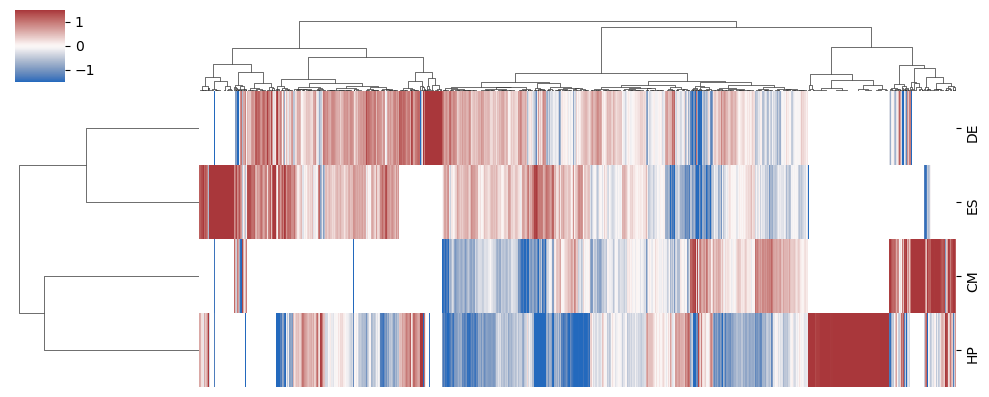

In [49]:
TF_expr = pd.concat(
    {
        "CM": CM_ntc_TF_expr.iloc[:, 0],
        "HP": HP_ntc_TF_expr.iloc[:, 0],
        "DE": DE_ntc_TF_expr.iloc[:, 0],
        "ES": ES_ntc_TF_expr.iloc[:, 0],
    },
    axis=1,
    join="outer",
).fillna(0)
print(TF_expr.shape)

pseudocount = 1

TF_expr_log2fc = np.log2(
    (TF_expr + pseudocount)
    .div(TF_expr.add(pseudocount).mean(axis=1), axis=0)
)#.rename(columns={'HP': 'Hep'})
print(TF_expr_log2fc.shape)

g = sns.clustermap(
    TF_expr_log2fc.T,
    mask=TF_expr.T.eq(0),
    cmap="vlag",
    vmax=1.5, vmin=-1.5,
    center=0,
    method='ward',
    metric='euclidean',
    figsize=(10, 4),
    yticklabels=True,
    xticklabels=False,
)

plt.show()

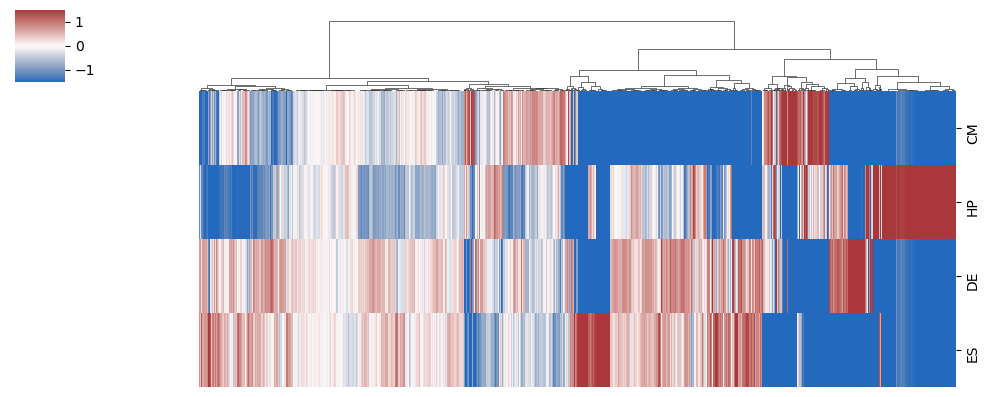

In [50]:
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import pdist

var_score = TF_expr_log2fc.std(axis=1)

X = TF_expr_log2fc.copy()
X["__var__"] = var_score * 3

col_linkage = linkage(
    X,
    method="ward",
    metric="euclidean",
)

g = sns.clustermap(
    TF_expr_log2fc.T,
    # mask=TF_expr.T.eq(0),
    col_linkage=col_linkage,
    row_cluster=False,
    cmap="vlag",
    vmax=1.5,
    vmin=-1.5,
    center=0,
    figsize=(10, 4),
    yticklabels=True,
    xticklabels=False,
)

plt.show()

In [35]:
print('Number of Expressed TF')
TF_expr.ne(0).sum(0)

CM     721
HP    1070
DE     965
ES     927
dtype: int64

In [40]:
TF_expr.sort_values('ES', ascending=False)

,CM,HP,DE,ES
NCL,865.043640,556.542542,771.928894,1465.121826
HMGA1,408.063141,83.787384,640.390930,1145.066162
XRCC5,392.332672,362.894348,849.631409,1087.387451
YBX1,720.485413,623.009277,602.006592,1067.974609
RERE,436.971039,604.842102,1495.607788,1054.229004
...,...,...,...,...
NR2F2,0.000000,100.009674,0.000000,0.000000
MESP1,0.000000,41.392456,0.000000,0.000000
ARNT2,0.000000,39.455402,24.715033,0.000000
ZSCAN29,0.000000,9.994225,0.000000,0.000000


#### Cluster TFs based on their expression patterns across datasets

In [166]:
import anndata as ad
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# X = TF_expr_log2fc.loc[TF_expr.mean(axis=1) > 10].copy()
X = TF_expr_log2fc.copy()
print(X.shape)
X = X.replace([np.inf, -np.inf], np.nan).dropna()

adata = ad.AnnData(X=X.values.astype(np.float32))
adata.obs_names = X.index.astype(str)
adata.var_names = X.columns.astype(str)

adata.obs["mean_expr"] = TF_expr.loc[X.index].mean(axis=1).values
adata.obs["min_expr"] = TF_expr.loc[X.index].min(axis=1).values
adata.obs["log2fc_sd"] = X.std(axis=1).values
adata.obs["max_abs_log2fc"] = X.abs().max(axis=1).values

sc.tl.pca(adata)

sc.pp.neighbors(
    adata,
    # use_rep="X",
    n_neighbors=25,
    metric="euclidean",
)

sc.tl.leiden(
    adata,
    resolution=0.5,
    key_added="leiden_expr",
    random_state=0,
)

(1221, 4)


/users/yyang117/tmp/ipykernel_1368170/2387822221.py:9: UserWarning: The palette list has more values (20) than needed (13), which may not be intended.
  sns.scatterplot(


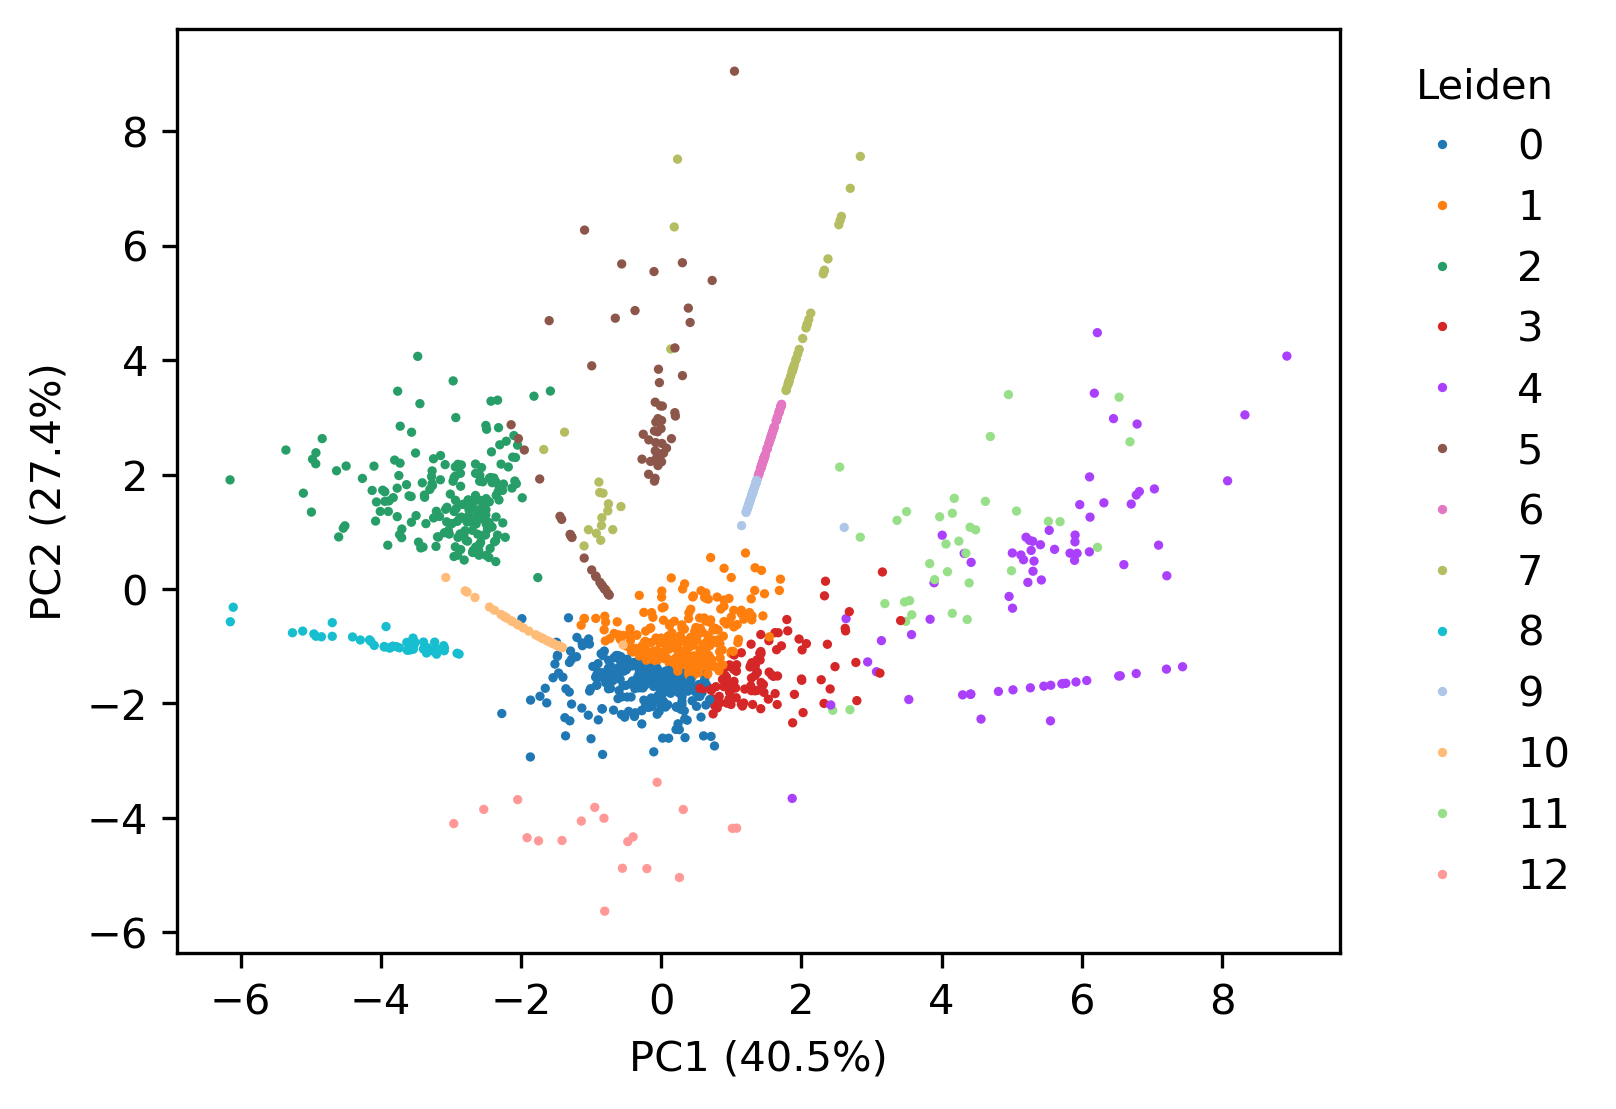

In [167]:
pca_df = pd.DataFrame(
    adata.obsm["X_pca"][:, :2],
    index=adata.obs_names,
    columns=["PC1", "PC2"],
).join(adata.obs)

fig, ax = plt.subplots(figsize=(5, 4), dpi=300)

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="leiden_expr", palette=sc.pl.palettes.default_20,
    # hue="mean_expr", hue_norm=(2, 400),
    s=5,
    lw=0,
    ax=ax,
)

ax.set_xlabel(f"PC1 ({adata.uns['pca']['variance_ratio'][0] * 100:.1f}%)")
ax.set_ylabel(f"PC2 ({adata.uns['pca']['variance_ratio'][1] * 100:.1f}%)")
ax.legend(title="Leiden", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)

plt.show()

In [168]:
cluster_summary = (
    adata.obs
    .groupby("leiden_expr")
    .agg(
        n_TF=("mean_expr", "size"),
        mean_expr=("mean_expr", "median"),
        min_expr=("min_expr", "median"),
        log2fc_sd=("log2fc_sd", "median"),
        max_abs_log2fc=("max_abs_log2fc", "median"),
    )
    .sort_values("log2fc_sd")
)

cluster_summary

/users/yyang117/tmp/ipykernel_1368170/207145042.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("leiden_expr")


,n_TF,mean_expr,min_expr,log2fc_sd,max_abs_log2fc
leiden_expr,,,,,
1,243,84.834930,56.100155,0.390832,0.510147
3,102,43.440498,23.442055,0.705492,0.908092
0,245,99.371918,40.016163,0.804815,1.096231
9,40,1.669408,0.000000,1.470308,1.524119
6,57,2.812198,0.000000,1.807284,1.930623
10,39,5.740497,0.000000,2.241692,2.664954
2,199,17.601292,0.000000,2.323326,4.210731
5,70,8.184547,0.000000,2.393504,3.199179
7,51,7.192782,0.000000,2.427986,3.034353


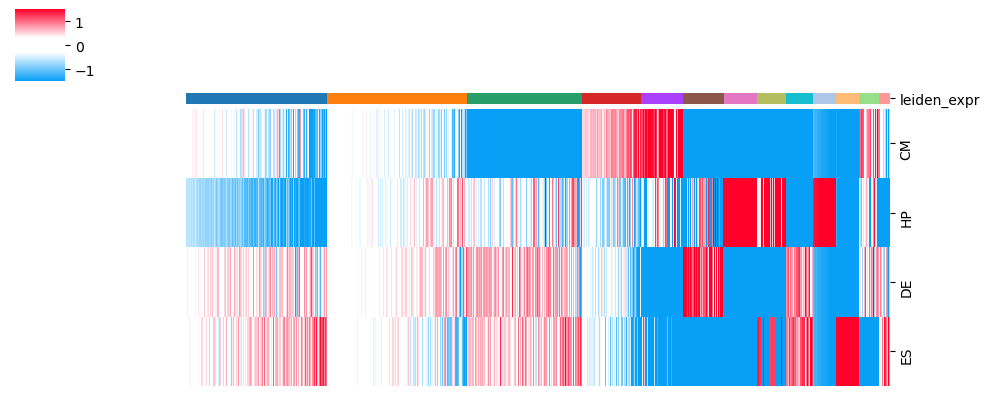

In [170]:
from matplotlib.colors import to_hex
import matplotlib.colors as clr

ordered_genes = (
    adata.obs
    .sort_values(["leiden_expr", "log2fc_sd"])
    .index
)

clusters = list(adata.obs["leiden_expr"].cat.categories)

colors = sc.pl.palettes.default_20[:len(clusters)]

lut = dict(zip(
    clusters,
    [to_hex(c) for c in colors]
))

row_colors = (
    adata.obs.loc[ordered_genes, "leiden_expr"]
    .astype(str)
    .map(lut)
)

cmap = clr.LinearSegmentedColormap.from_list(
    "custom_red_blue_white_broad",
    [
        (0.0, "#089FF7"),
        (0.4, "white"),
        (0.6, "white"),
        (1.0, "#FF002B"),
    ],
)

g = sns.clustermap(
    X.loc[ordered_genes].T,
    row_cluster=False,
    col_cluster=False,
    col_colors=row_colors,
    cmap=cmap,
    center=0,
    vmax=1.5,
    vmin=-1.5,
    figsize=(10, 4),
    yticklabels=True,
    xticklabels=False,
)

plt.show()

In [171]:
np.log2(TF_expr+pseudocount).loc[ordered_genes].quantile([.02, .5, .98])

,CM,HP,DE,ES
0.02,0.000000,0.000000,0.000000,0.000000
0.50,5.205986,4.688119,5.282648,5.080870
0.98,8.639400,8.347101,9.165820,9.112766


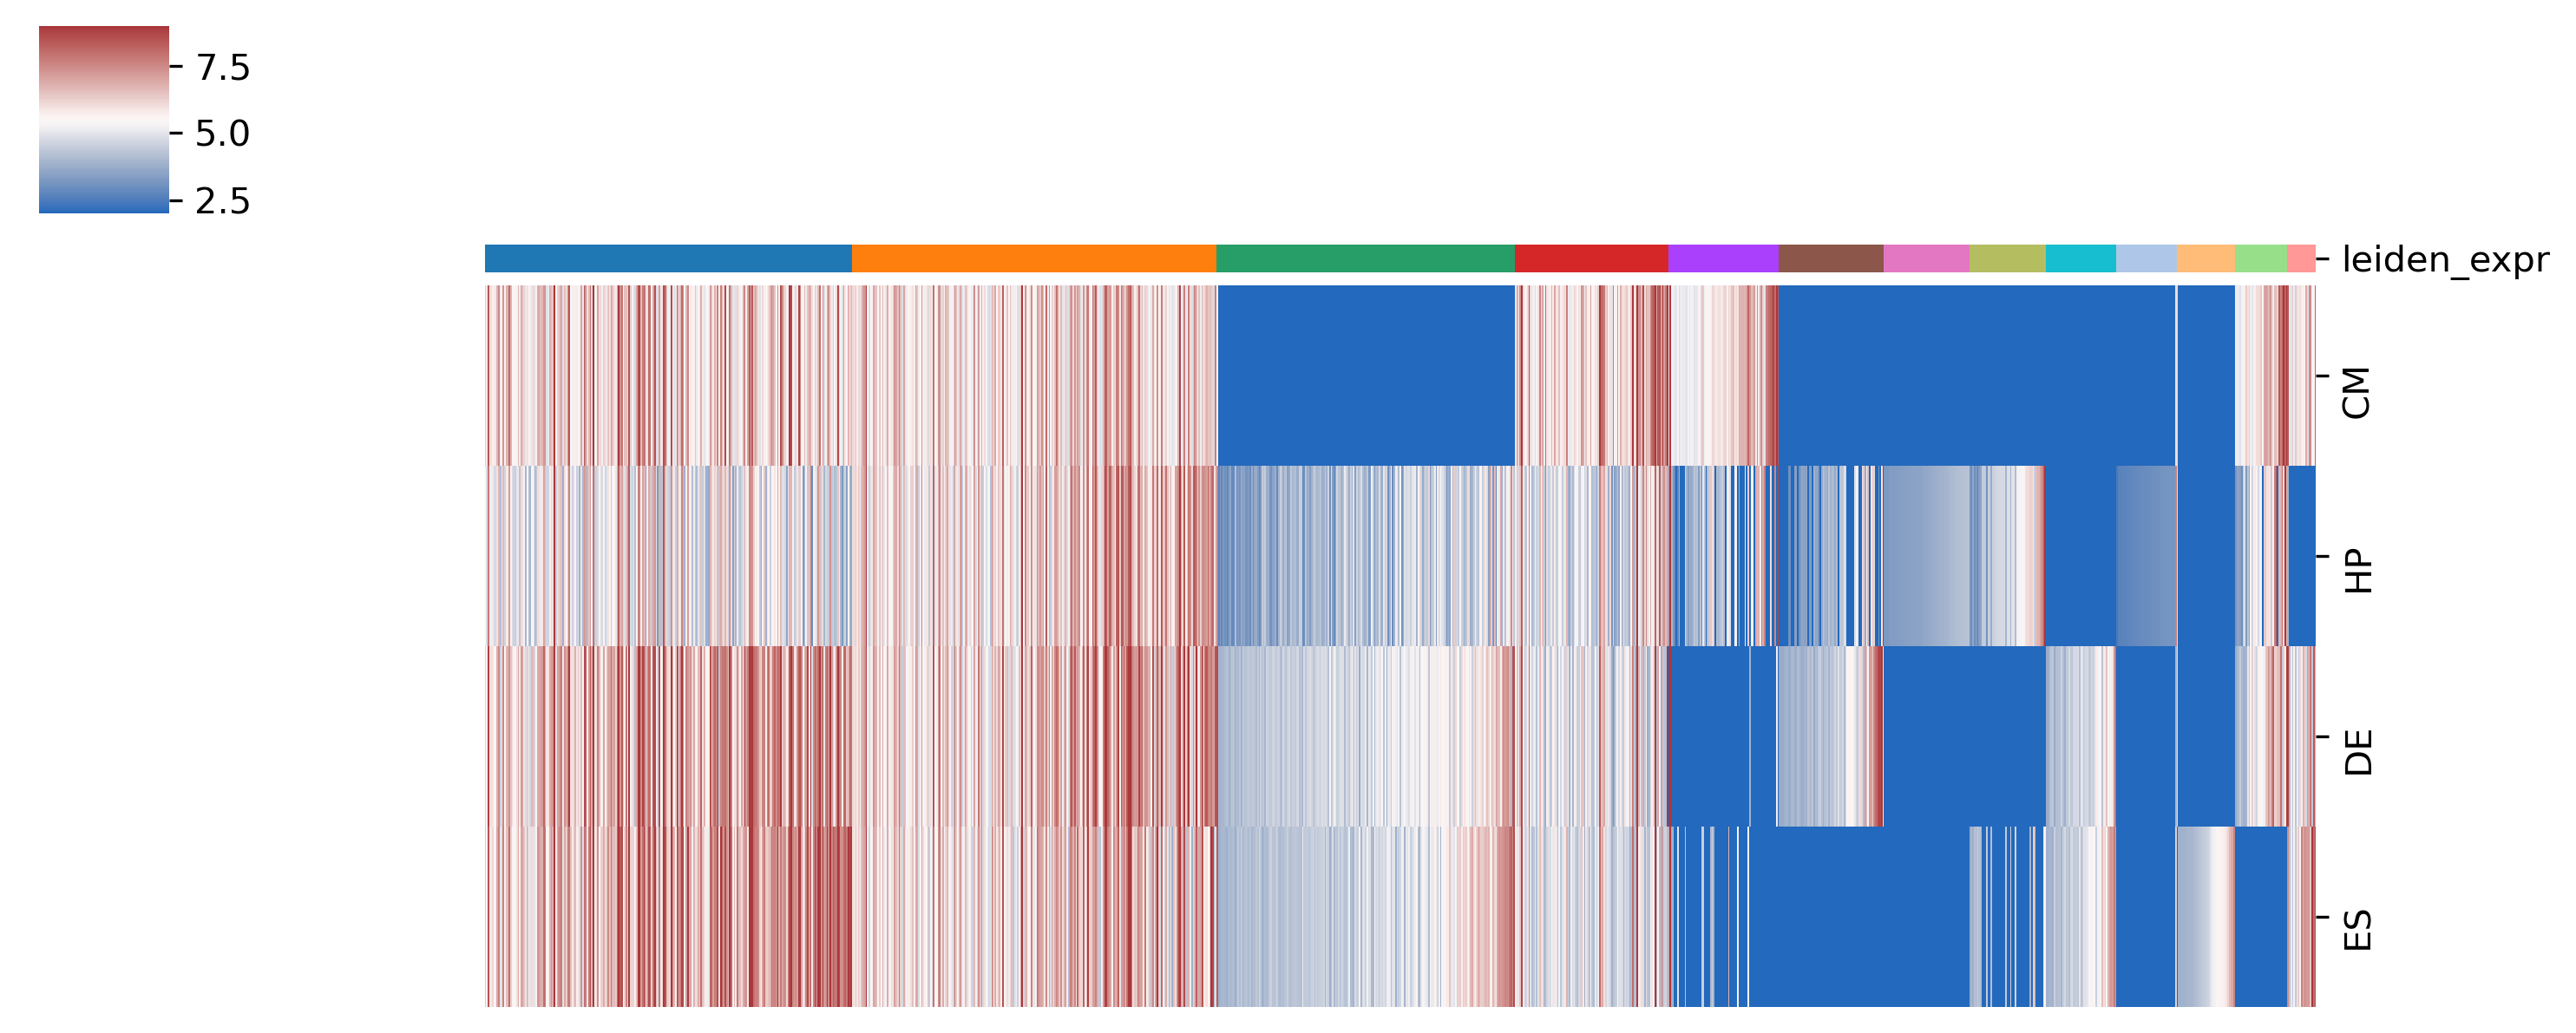

In [288]:
g = sns.clustermap(
    np.log2(TF_expr + pseudocount).loc[ordered_genes].T,
    row_cluster=False,
    col_cluster=False,
    col_colors=row_colors,
    cmap="vlag",
    center=5.5, vmin=2, vmax=9,
    figsize=(10, 4),
    yticklabels=True,
    xticklabels=False,
)

g.fig.set_dpi(300)

plt.show()

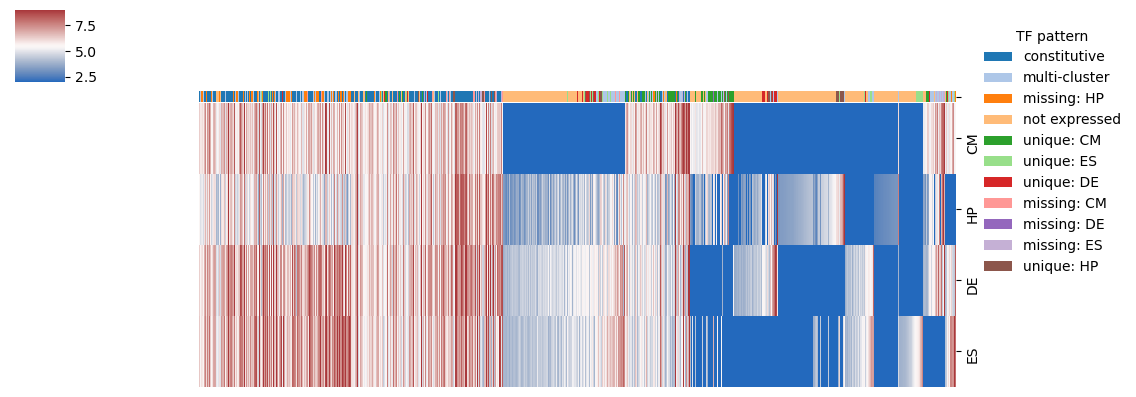

In [260]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

log_expr = np.log2(TF_expr + pseudocount).loc[ordered_genes]
expr_bin = log_expr.ge(5.5)

def annotate_pattern(x):
    n = x.sum()
    if n == len(x):
        return 'constitutive'
    if n == 0:
        return 'not expressed'
    if n == 1:
        return f'unique: {x.index[x][0]}'
    if n == len(x) - 1:
        return f'missing: {x.index[~x][0]}'
    return 'multi-cluster'

gene_pattern = expr_bin.apply(annotate_pattern, axis=1).loc[ordered_genes]

pattern_colors = dict(zip(
    gene_pattern.unique(),
    sns.color_palette('tab20', gene_pattern.nunique())
))

col_colors = gene_pattern.map(pattern_colors)

g = sns.clustermap(
    log_expr.T,
    row_cluster=False,
    col_cluster=False,
    col_colors=col_colors,
    cmap='vlag',
    center=5.5, vmin=2, vmax=9,
    figsize=(10, 4),
    yticklabels=True,
    xticklabels=False,
)

for label, color in pattern_colors.items():
    g.ax_col_dendrogram.bar(0, 0, color=color, label=label, linewidth=0)

g.ax_col_dendrogram.legend(
    title='TF pattern',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=False,
)

plt.show()

#### Identify way to call DEG on the calibrated datasets 
1. fixed p-value doesn't work
2. fixed p-value & fixed magnitude of effect size (log2fc) doesn't work
3. fixed p-value & 3 magnitude of effecft size cutoff by std. dev. above mean doesn't work

The only thing that kind of worked was taking the topN ranked by effect size (and additionally pre-cut off by p-value)
-- thought: p-value is more influenced by power than effect size. So maybe first filter by a fixed effect size (say abs(log2fc)>=0.5) and then retain the smallest 20,000 by p-values

In [ ]:
deg_paths = {
    "CM": os.path.join(
        workdir,
        "Hon_WTC11-cardiomyocyte-differentiation_TF-Perturb-seq",
        "calibration",
        "Hon_WTC11-cardiomyocyte-differentiation_TF-Perturb-seq_2026_04_19_no_spacer_calibrated_all_results.tsv",
    ),
    "HP": os.path.join(
        workdir,
        "Gersbach_WTC11-hepatocyte-differentiation_TF-Perturb-seq",
        "calibration",
        "Gersbach_WTC11-hepatocyte-differentiation_TF-Perturb-seq_sara_synapse_syn74842722_calibrated_all_results.tsv",
    ),
    "DE": os.path.join(
        workdir,
        "Huangfu_HUES8-definitive-endoderm-differentiation_TF-Perturb-seq",
        "calibration",
        "Huangfu_HUES8-definitive-endoderm-differentiation_TF-Perturb-seq_muddy_penguin_calibrated_all_results.tsv",
    ),
    "ES": os.path.join(
        workdir,
        "Huangfu_HUES8-embryonic-stemcell-differentiation_TF-Perturb-seq",
        "calibration",
        "Huangfu_HUES8-embryonic-stemcell-differentiation_TF-Perturb-seq_sceptre_v1_calibrated_all_results.tsv",
    ),
}

deg_tables = {}

for ds, path in deg_paths.items():
    DEG = pd.read_csv(path, sep="\t")

    ribo_mt = (
        DEG["tested_gene_symbol"].str.startswith("MT-", na=False)
        | DEG["tested_gene_symbol"].str.match(r"^RP[SL]\d+", na=False)
    )

    DEG_no_ribo_mt = DEG.loc[~ribo_mt].copy()
    DEG_no_ribo_mt["dataset"] = ds

    globals()[f"{ds}_DEG"] = DEG
    globals()[f"{ds}_DEG_no_ribo_mt"] = DEG_no_ribo_mt

    deg_tables[ds] = DEG_no_ribo_mt

    print(ds, DEG.shape, DEG_no_ribo_mt.shape)

all_DEG_no_ribo_mt = pd.concat(deg_tables.values(), ignore_index=True)

DEG_sig_count_all = (
    pd.concat({
        ds: df.loc[df.empirical_pval_adj.le(0.01)]
              .groupby("element_symbol")["tested_gene_symbol"]
              .count()
        for ds, df in deg_tables.items()
    }, axis=1)
    .fillna(0)
    .astype(int)
)

DEG_sig_count_all["total"] = DEG_sig_count_all.sum(axis=1)
DEG_sig_count_all = DEG_sig_count_all.sort_values("total", ascending=False)

In [231]:
cutoffs = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 2e-3, 5e-3, 1e-2, 2e-2, 5e-2, 1e-1, 2e-1]
cutoff_labels = [f"{x:g}" for x in cutoffs]

In [246]:
out = []

for ds, df in deg_tables.items():
    print(f"\n=== {ds} ===")
    print(f"table shape: {df.shape}")

    # lfc_cutoff = df["log2fc"].abs().nlargest(min(500, len(df))).iloc[-1] * 0.25
    # lfc_cutoff = 0.4
    lfc_cutoff = df['log2fc'].abs().mean() + df['log2fc'].abs().std() * 2
    
    print(f"|log2fc| cutoff: {lfc_cutoff:.4f}")

    genes = pd.Index(df["element_symbol"].dropna().astype(str).unique())
    or_mask = genes.str.contains(r"^OR", regex=True, case=False, na=False)

    print(f"# elements:     {len(genes):>8}")
    print(f"# OR elements:  {or_mask.sum():>8}")
    print(f"# non OR elems: {(~or_mask).sum():>8}")

    for cutoff in cutoffs:
        sig = df.loc[
            df["empirical_pval_adj"].le(cutoff)
            & df["log2fc"].abs().ge(lfc_cutoff)
        ].copy()

        sig_or = sig["element_symbol"].astype(str).str.contains(
            r"^OR", regex=True, case=False, na=False
        )

        OR_total_DEG = sig_or.sum()
        non_OR_total_DEG = (~sig_or).sum()
        total_DEG = len(sig)

        cnt = (
            sig
            .groupby("element_symbol")["tested_gene_symbol"]
            .count()
            .reindex(genes, fill_value=0)
        )

        OR_vals = cnt.loc[genes[or_mask]]
        non_OR_vals = cnt.loc[genes[~or_mask]]

        print(
            f"cutoff={cutoff:<8g} "
            f"total DEG={total_DEG:>9} | "
            f"OR mean={OR_vals.mean():>7.2f} | "
            f"non OR mean={non_OR_vals.mean():>7.2f} | "
            f"OR DEG frac={OR_total_DEG / total_DEG if total_DEG else 0:>6.2%}"
        )

        out.append({
            "dataset": ds,
            "cutoff": cutoff,
            "cutoff_label": f"{cutoff:g}",
            "log2fc_cutoff": lfc_cutoff,
            "total_DEG": total_DEG,
            "OR_total_DEG": OR_total_DEG,
            "non_OR_total_DEG": non_OR_total_DEG,
            "OR_frac_total_DEG": OR_total_DEG / total_DEG if total_DEG else 0,
            "non_OR_frac_total_DEG": non_OR_total_DEG / total_DEG if total_DEG else 0,
            "OR_n_elements": or_mask.sum(),
            "non_OR_n_elements": (~or_mask).sum(),
            "OR_mean_DEG_per_element": OR_vals.mean(),
            "non_OR_mean_DEG_per_element": non_OR_vals.mean(),
            "OR_median_DEG_per_element": OR_vals.median(),
            "non_OR_median_DEG_per_element": non_OR_vals.median(),
        })

cutoff_summary = pd.DataFrame(out)


=== CM ===
table shape: (17078976, 13)
|log2fc| cutoff: 0.3759
# elements:         2060
# OR elements:        99
# non OR elems:     1961
cutoff=1e-05    total DEG=     5694 | OR mean=   0.03 | non OR mean=   2.90 | OR DEG frac= 0.05%
cutoff=5e-05    total DEG=     6609 | OR mean=   0.05 | non OR mean=   3.37 | OR DEG frac= 0.08%
cutoff=0.0001   total DEG=     7155 | OR mean=   0.06 | non OR mean=   3.65 | OR DEG frac= 0.08%
cutoff=0.0005   total DEG=     8682 | OR mean=   0.16 | non OR mean=   4.42 | OR DEG frac= 0.18%
cutoff=0.001    total DEG=     9662 | OR mean=   0.33 | non OR mean=   4.91 | OR DEG frac= 0.34%
cutoff=0.002    total DEG=    10761 | OR mean=   0.49 | non OR mean=   5.46 | OR DEG frac= 0.46%
cutoff=0.005    total DEG=    12684 | OR mean=   0.75 | non OR mean=   6.43 | OR DEG frac= 0.58%
cutoff=0.01     total DEG=    14777 | OR mean=   1.15 | non OR mean=   7.48 | OR DEG frac= 0.77%
cutoff=0.02     total DEG=    17626 | OR mean=   1.74 | non OR mean=   8.90 | OR DEG 

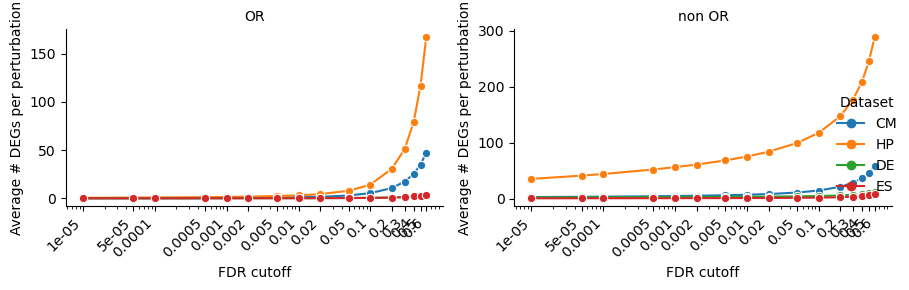

In [241]:
avg_long = cutoff_summary.melt(
    id_vars=["dataset", "cutoff", "cutoff_label"],
    value_vars=["OR_mean_DEG_per_element", "non_OR_mean_DEG_per_element"],
    var_name="group",
    value_name="avg_DEG",
)

avg_long["group"] = avg_long["group"].map({
    "OR_mean_DEG_per_element": "OR",
    "non_OR_mean_DEG_per_element": "non OR",
})

g = sns.relplot(
    data=avg_long,
    x="cutoff",
    y="avg_DEG",
    hue="dataset",
    col="group",
    kind="line",
    marker="o",
    facet_kws={"sharey": False},
    height=3,
    aspect=1.4,
)

for ax in g.axes.flat:
    ax.set_xscale("log")
    ax.set_xticks(cutoffs)
    ax.set_xticklabels(cutoff_labels, rotation=45, ha="right")
    ax.set_xlabel("FDR cutoff")
    ax.set_ylabel("Average # DEGs per perturbation")

g.set_titles("{col_name}")
g.legend.set_title("Dataset")

plt.tight_layout()
plt.show()

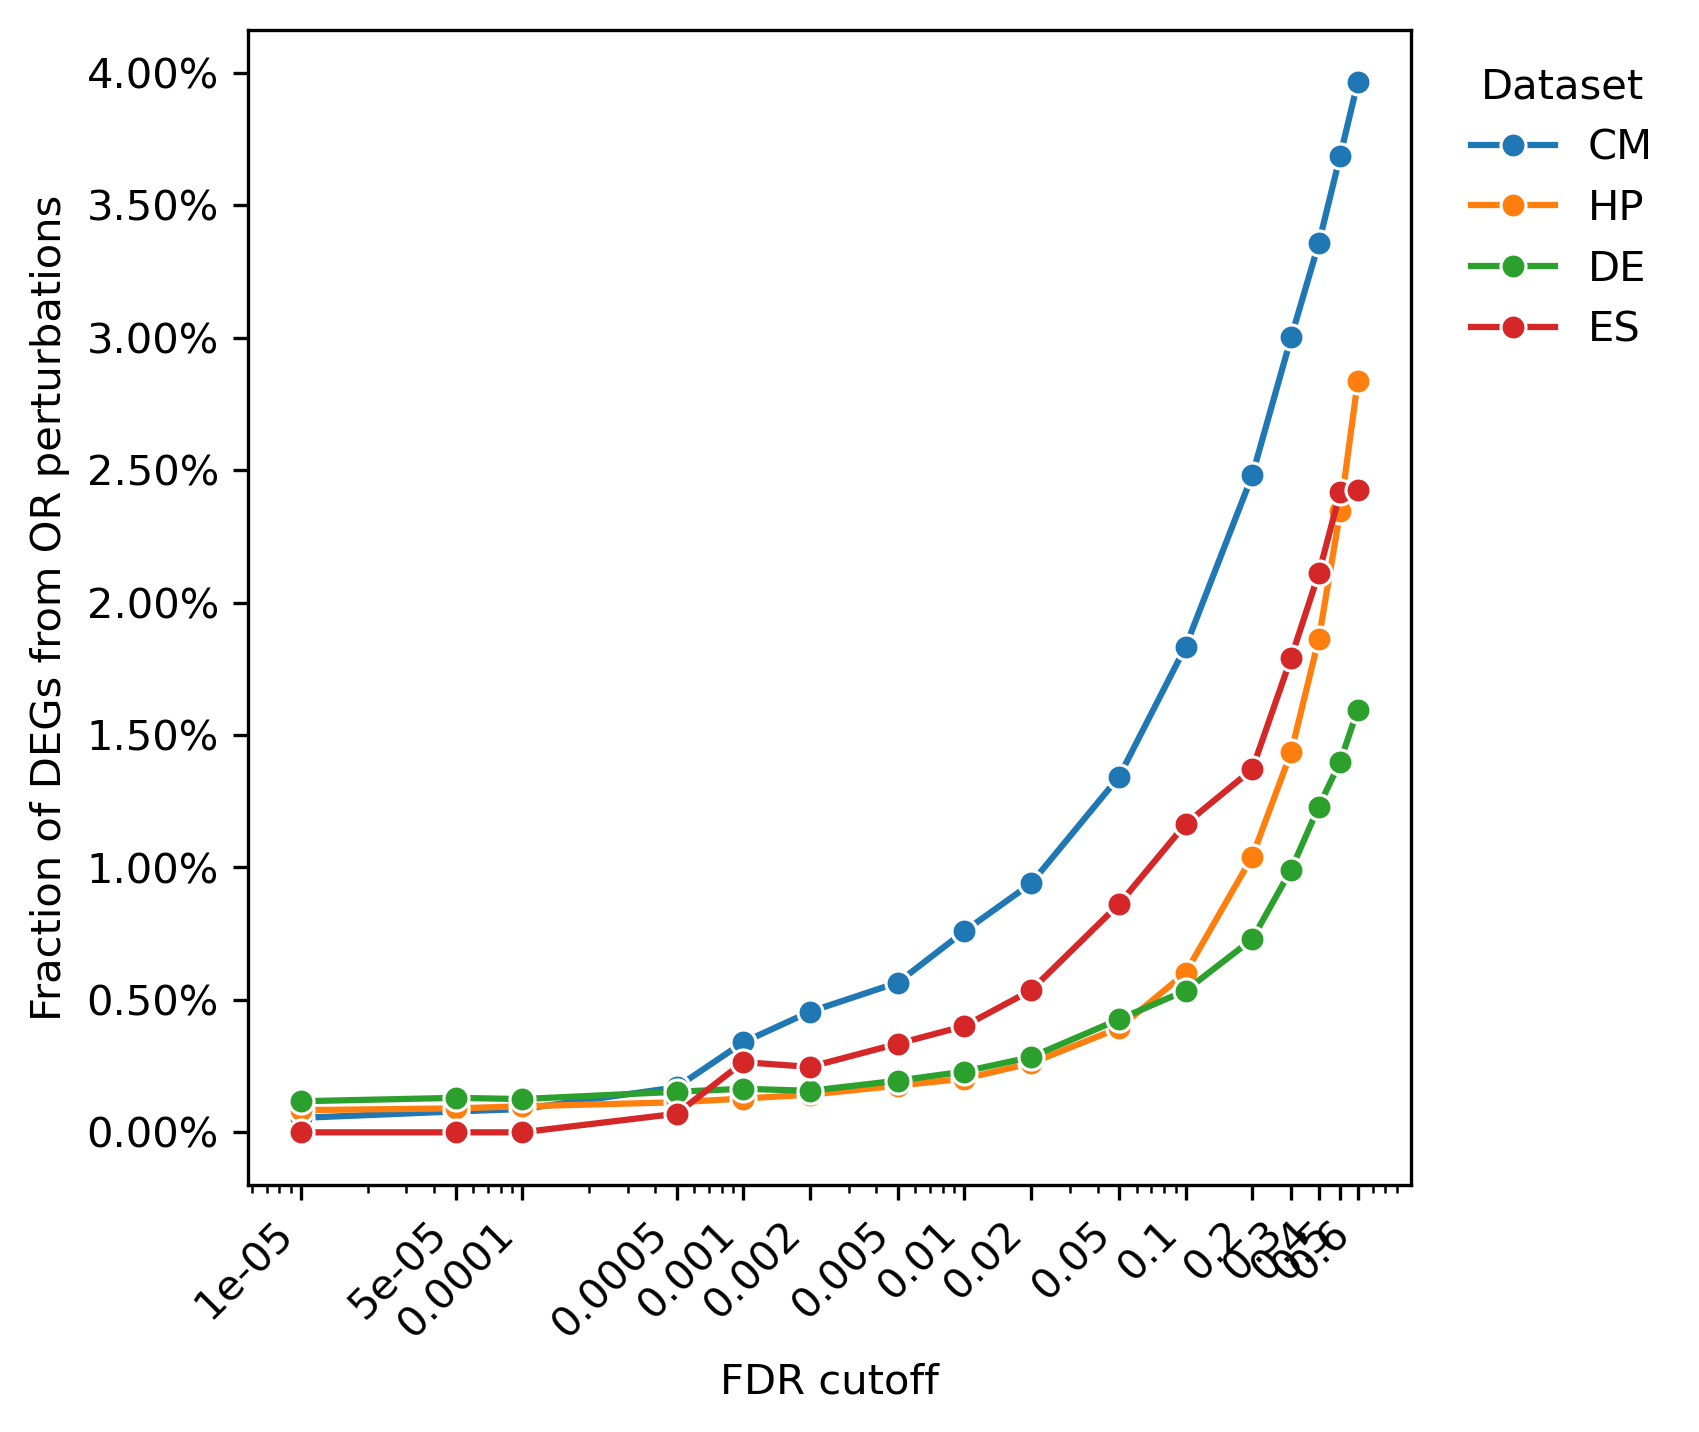

In [242]:
frac_deg = cutoff_summary.copy()
frac_deg["cutoff_label"] = frac_deg["cutoff"].map(lambda x: f"{x:g}")

fig, ax = plt.subplots(figsize=(5, 5), dpi=300)

sns.lineplot(
    data=frac_deg,
    x="cutoff",
    y="OR_frac_total_DEG",
    hue="dataset",
    marker="o",
    ax=ax,
)

ax.set_xscale("log")
ax.set_xticks(cutoffs)
ax.set_xticklabels(cutoff_labels, rotation=45, ha="right")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))

ax.set_xlabel("FDR cutoff")
ax.set_ylabel("Fraction of DEGs from OR perturbations")
ax.legend(title="Dataset", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)

plt.show()

In [243]:
target = 1

controlled = []

for ds, d in cutoff_summary.sort_values("cutoff").groupby("dataset"):
    d = d.sort_values("OR_mean_DEG_per_element")

    if target < d["OR_mean_DEG_per_element"].min() or target > d["OR_mean_DEG_per_element"].max():
        closest = d.iloc[(d["OR_mean_DEG_per_element"] - target).abs().argmin()]
        controlled.append({
            "dataset": ds,
            "method": "closest",
            "cutoff": closest["cutoff"],
            "OR_mean_DEG": closest["OR_mean_DEG_per_element"],
            "non_OR_mean_DEG": closest["non_OR_mean_DEG_per_element"],
        })
        continue

    cutoff_at_target = np.interp(
        target,
        d["OR_mean_DEG_per_element"],
        d["cutoff"],
    )

    non_OR_at_target = np.interp(
        target,
        d["OR_mean_DEG_per_element"],
        d["non_OR_mean_DEG_per_element"],
    )

    controlled.append({
        "dataset": ds,
        "method": "interpolated",
        "cutoff": cutoff_at_target,
        "OR_mean_DEG": target,
        "non_OR_mean_DEG": non_OR_at_target,
    })

controlled_summary = pd.DataFrame(controlled)
controlled_summary

,dataset,method,cutoff,OR_mean_DEG,non_OR_mean_DEG
0,CM,interpolated,0.009324,1,6.804457
1,DE,interpolated,0.235294,1,6.010739
2,ES,interpolated,0.262264,1,2.984548
3,HP,interpolated,0.000281,1,47.693409



=== CM ===
table shape: (17078976, 13)


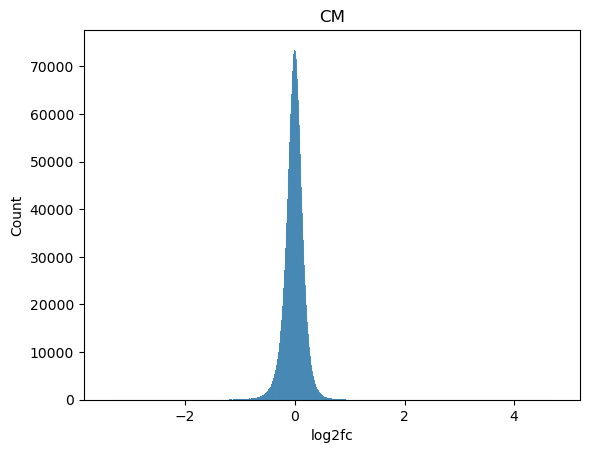


=== HP ===
table shape: (26305056, 13)


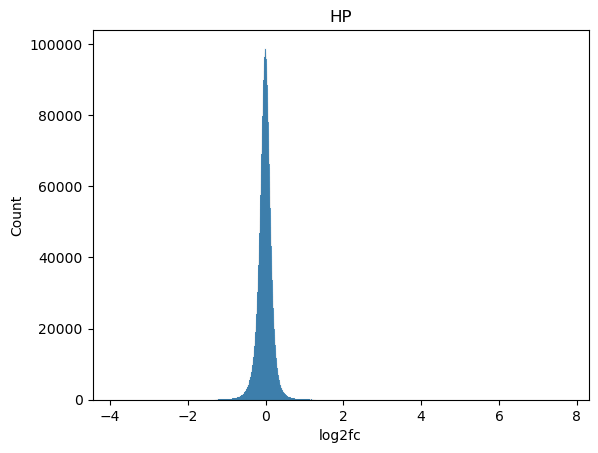


=== DE ===
table shape: (22600320, 13)


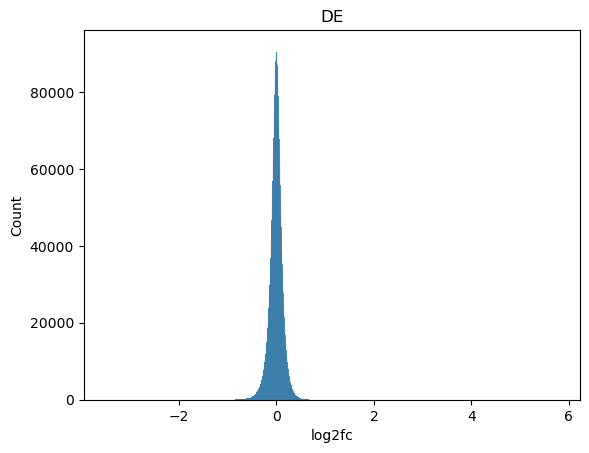


=== ES ===
table shape: (22440592, 13)


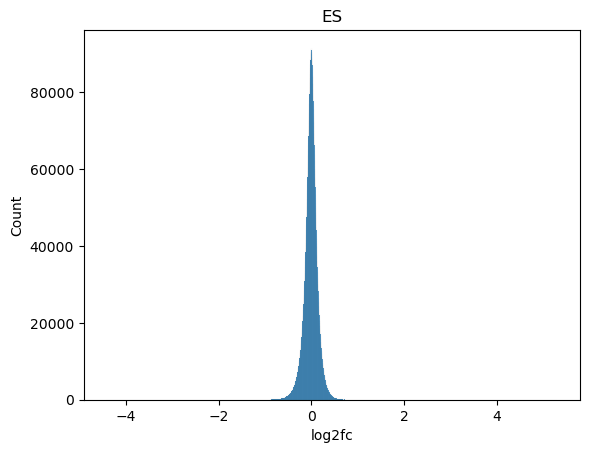

In [247]:
for ds, df in deg_tables.items():
    print(f"\n=== {ds} ===")
    print(f"table shape: {df.shape}")

    # lfc_cutoff = df["log2fc"].abs().nlargest(min(500, len(df))).iloc[-1] * 0.25
    # lfc_cutoff = 0.4
    lfc_cutoff = df['log2fc'].abs().mean() + df['log2fc'].abs().std() * 2
    sns.histplot(df['log2fc'])
    plt.title(ds)
    plt.show()

In [258]:
topNs = [2000, 3000, 5000, 7000, 10_000]

topN_summary = []
topN_sig_deg = {}
topN_deg_count = {}
topN_deg_count_long = []

for ds, df in deg_tables.items():
    genes = pd.Index(df["element_symbol"].dropna().astype(str).unique())
    or_mask = genes.str.contains(r"^OR", regex=True, case=False, na=False)

    print(f"\n=== {ds} ===")

    for N in topNs:
        up = df.nlargest(N, "log2fc")
        down = df.nsmallest(N, "log2fc")
        sig = pd.concat([up, down]).drop_duplicates()

        sig_or = sig["element_symbol"].astype(str).str.contains(
            r"^OR", regex=True, case=False, na=False
        )

        cnt = (
            sig
            .groupby("element_symbol")["tested_gene_symbol"]
            .count()
            .reindex(genes, fill_value=0)
            .rename("n_DEG")
            .to_frame()
            .assign(
                dataset=ds,
                N_each_side=N,
                is_OR=or_mask,
                group=np.where(or_mask, "OR", "non OR"),
            )
        )

        OR_vals = cnt.loc[cnt.is_OR, "n_DEG"]
        non_OR_vals = cnt.loc[~cnt.is_OR, "n_DEG"]

        topN_sig_deg[(ds, N)] = sig
        topN_deg_count[(ds, N)] = cnt
        topN_deg_count_long.append(cnt.reset_index(names="element_symbol"))

        print(
            f"N={N:<7} "
            f"total DEG={len(sig):>8} | "
            f"OR frac={sig_or.mean():>6.2%} | "
            f"OR avg={OR_vals.mean():>7.2f}, "
            f"OR <=1={OR_vals.le(1).mean():>6.2%} | "
            f"non OR avg={non_OR_vals.mean():>7.2f}, "
            f"non OR <=1={non_OR_vals.le(1).mean():>6.2%}"
        )

        topN_summary.append({
            "dataset": ds,
            "N_each_side": N,
            "total_DEG": len(sig),
            "OR_total_DEG": sig_or.sum(),
            "non_OR_total_DEG": (~sig_or).sum(),
            "OR_frac_total_DEG": sig_or.mean(),
            "non_OR_frac_total_DEG": (~sig_or).mean(),
            "OR_mean_DEG_per_element": OR_vals.mean(),
            "non_OR_mean_DEG_per_element": non_OR_vals.mean(),
            "OR_median_DEG_per_element": OR_vals.median(),
            "non_OR_median_DEG_per_element": non_OR_vals.median(),
            "OR_frac_0_DEG": OR_vals.eq(0).mean(),
            "OR_frac_le1_DEG": OR_vals.le(1).mean(),
            "non_OR_frac_0_DEG": non_OR_vals.eq(0).mean(),
            "non_OR_frac_le1_DEG": non_OR_vals.le(1).mean(),
        })

topN_summary = pd.DataFrame(topN_summary)
topN_deg_count_long = pd.concat(topN_deg_count_long, ignore_index=True)

topN_summary


=== CM ===
N=2000    total DEG=    4000 | OR frac= 0.03% | OR avg=   0.01, OR <=1=100.00% | non OR avg=   2.04, non OR <=1=85.77%
N=3000    total DEG=    6000 | OR frac= 0.02% | OR avg=   0.01, OR <=1=100.00% | non OR avg=   3.06, non OR <=1=83.38%
N=5000    total DEG=   10000 | OR frac= 0.01% | OR avg=   0.01, OR <=1=100.00% | non OR avg=   5.09, non OR <=1=79.96%
N=7000    total DEG=   14000 | OR frac= 0.03% | OR avg=   0.04, OR <=1=98.99% | non OR avg=   7.13, non OR <=1=77.36%
N=10000   total DEG=   20000 | OR frac= 0.06% | OR avg=   0.11, OR <=1=98.99% | non OR avg=  10.18, non OR <=1=73.84%

=== HP ===
N=2000    total DEG=    4000 | OR frac= 0.85% | OR avg=   0.34, OR <=1=94.95% | non OR avg=   2.01, non OR <=1=80.83%
N=3000    total DEG=    6000 | OR frac= 0.78% | OR avg=   0.47, OR <=1=93.94% | non OR avg=   3.02, non OR <=1=74.25%
N=5000    total DEG=   10000 | OR frac= 0.88% | OR avg=   0.89, OR <=1=83.84% | non OR avg=   5.03, non OR <=1=64.61%
N=7000    total DEG=   14000 

,dataset,N_each_side,total_DEG,OR_total_DEG,non_OR_total_DEG,OR_frac_total_DEG,non_OR_frac_total_DEG,OR_mean_DEG_per_element,non_OR_mean_DEG_per_element,OR_median_DEG_per_element,non_OR_median_DEG_per_element,OR_frac_0_DEG,OR_frac_le1_DEG,non_OR_frac_0_DEG,non_OR_frac_le1_DEG
0,CM,2000,4000,1,3999,0.000250,0.999750,0.010101,2.037736,0.0,0.0,0.989899,1.000000,0.679755,0.857726
1,CM,3000,6000,1,5999,0.000167,0.999833,0.010101,3.056604,0.0,0.0,0.989899,1.000000,0.644059,0.833758
2,CM,5000,10000,1,9999,0.000100,0.999900,0.010101,5.094850,0.0,0.0,0.989899,1.000000,0.598674,0.799592
3,CM,7000,14000,4,13996,0.000286,0.999714,0.040404,7.132075,0.0,0.0,0.969697,0.989899,0.562468,0.773585
4,CM,10000,20000,11,19989,0.000550,0.999450,0.111111,10.182560,0.0,0.0,0.919192,0.989899,0.523202,0.738399
5,HP,2000,4000,34,3966,0.008500,0.991500,0.343434,2.012749,0.0,0.0,0.797980,0.949495,0.570117,0.808261
6,HP,3000,6000,47,5953,0.007833,0.992167,0.474747,3.020398,0.0,1.0,0.777778,0.939394,0.486486,0.742478
7,HP,5000,10000,88,9912,0.008800,0.991200,0.888889,5.026007,0.0,1.0,0.646465,0.838384,0.381948,0.646099
8,HP,7000,14000,118,13882,0.008429,0.991571,1.191919,7.041305,0.0,1.0,0.515152,0.797980,0.297807,0.574707
9,HP,10000,20000,173,19827,0.008650,0.991350,1.747475,10.047425,1.0,2.0,0.323232,0.636364,0.227945,0.475778


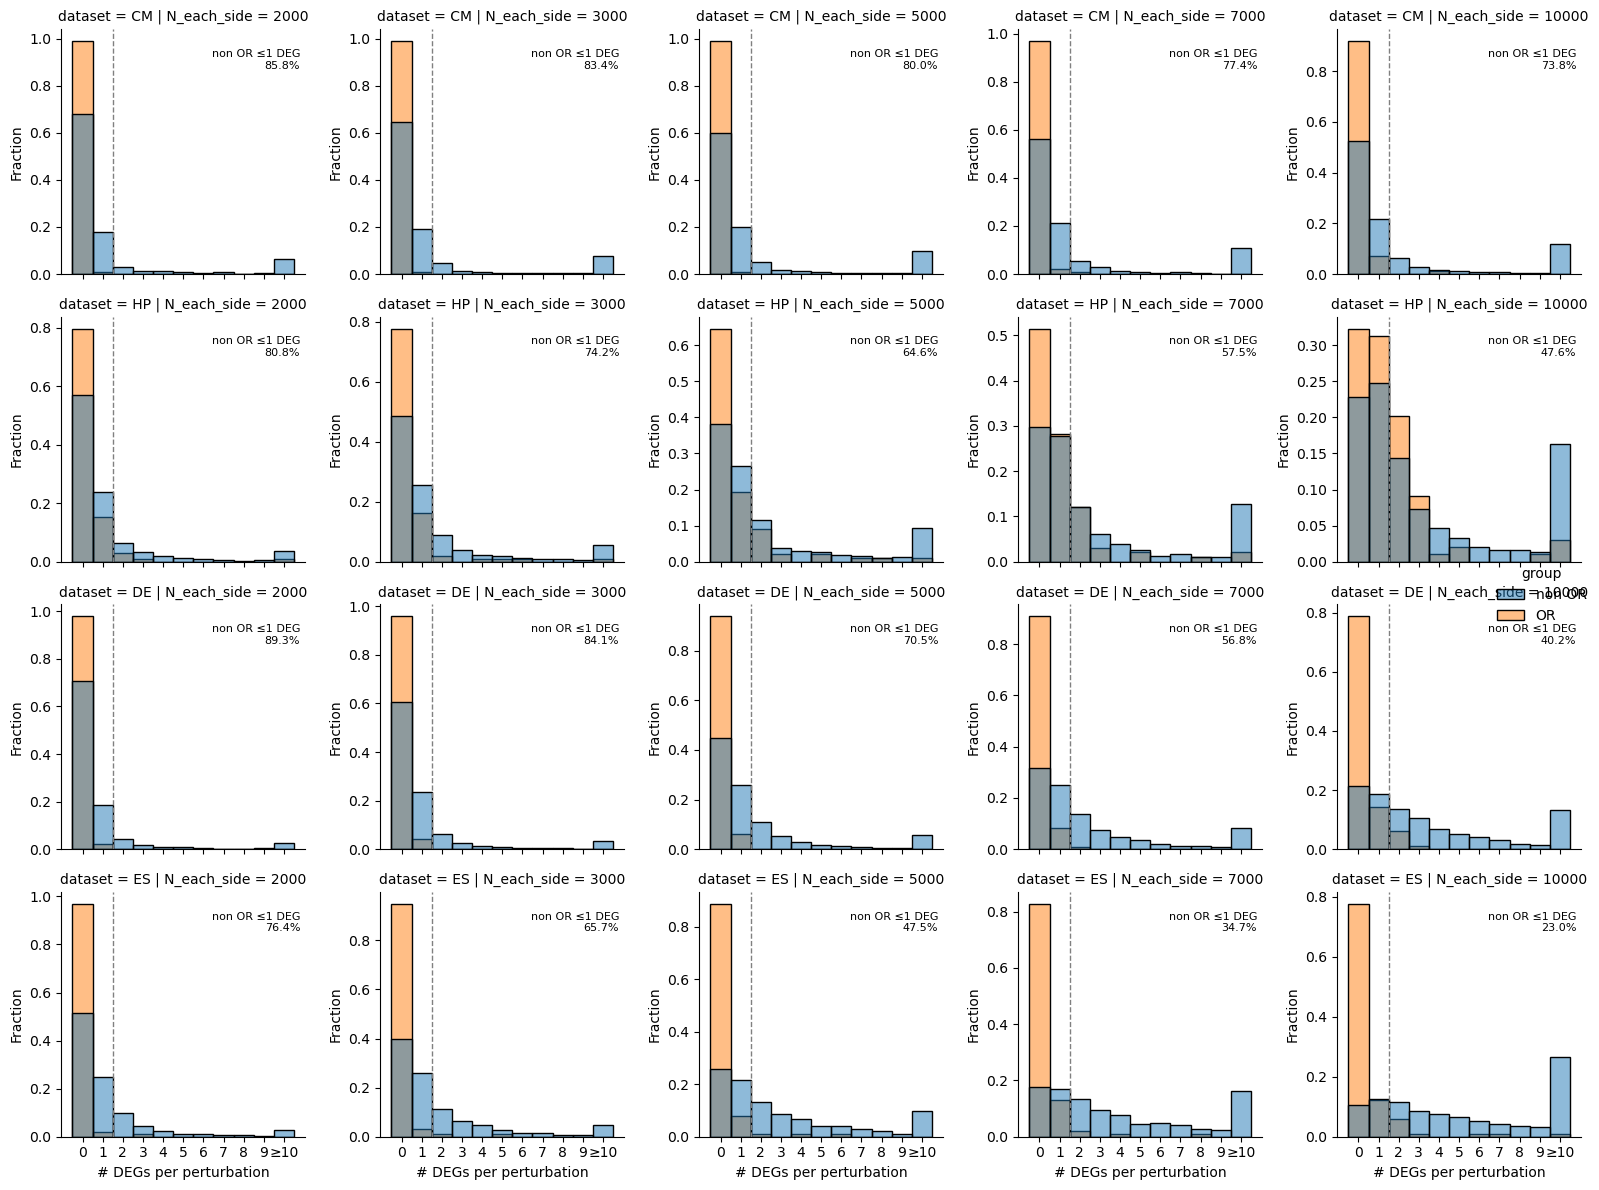

In [259]:
plot_cnt = topN_deg_count_long.copy()
plot_cnt["N_each_side"] = plot_cnt["N_each_side"].astype(str)
plot_cnt["n_DEG_plot"] = plot_cnt["n_DEG"].clip(upper=10)

non_or_le1 = (
    plot_cnt
    .loc[plot_cnt["group"].eq("non OR")]
    .groupby(["dataset", "N_each_side"])["n_DEG"]
    .apply(lambda x: x.le(1).mean())
)

g = sns.displot(
    data=plot_cnt[,
    x="n_DEG_plot",
    row="dataset",
    col="N_each_side",
    hue="group",
    bins=np.arange(-0.5, 11.5, 1),
    stat="proportion",
    common_norm=False,
    height=3,
    aspect=1,
    facet_kws={"sharex": True, "sharey": False},
)

for i, dataset in enumerate(g.row_names):
    for j, N in enumerate(g.col_names):
        ax = g.axes[i, j]

        frac = non_or_le1.get((dataset, N), np.nan)

        ax.axvline(1.5, ls="--", lw=1, c="gray")
        ax.text(
            0.98,
            0.92,
            f"non OR ≤1 DEG\n{frac:.1%}",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=8,
        )

        ax.set_xticks(range(11))
        ax.set_xticklabels([*map(str, range(10)), "≥10"])
        ax.set_xlabel("# DEGs per perturbation")
        ax.set_ylabel("Fraction")

plt.tight_layout()
plt.show()

In [306]:
topN_sig_deg = {}
topN_deg_count = {}
topN_deg_count_long = []

N = 20_000
P_COL = "empirical_pval_adj"  

for ds, df in deg_tables.items():
    genes = pd.Index(df["element_symbol"].dropna().astype(str).unique())
    or_mask = genes.str.contains(r"^OR", regex=True, case=False, na=False)

    print(f"\n=== {ds} ===")

    sig = (
        df.loc[df[P_COL].le(0.1)]
        .assign(abs_log2fc=lambda d: d["log2fc"].abs())
        .nlargest(N, "abs_log2fc")
        .drop_duplicates()
    )

    cnt = (
        sig
        .groupby("element_symbol")["tested_gene_symbol"]
        .count()
        .reindex(genes, fill_value=0)
        .rename("n_DEG")
        .to_frame()
        .assign(
            dataset=ds,
            N_by_abs_log2fc=N,
            p_cutoff=0.05,
            is_OR=or_mask,
            group=np.where(or_mask, "OR", "non OR"),
        )
        .query("n_DEG >= 10")
    )

    print(cnt.group.value_counts())

    topN_sig_deg[(ds, N)] = sig
    topN_deg_count[(ds, N)] = cnt
    topN_deg_count_long.append(cnt.reset_index(names="element_symbol"))

topN_deg_count_long = pd.concat(topN_deg_count_long, ignore_index=True)


=== CM ===
group
non OR    280
OR          2
Name: count, dtype: int64

=== HP ===
group
non OR    278
OR          2
Name: count, dtype: int64

=== DE ===
group
non OR    145
OR         11
Name: count, dtype: int64

=== ES ===
group
non OR    65
Name: count, dtype: int64


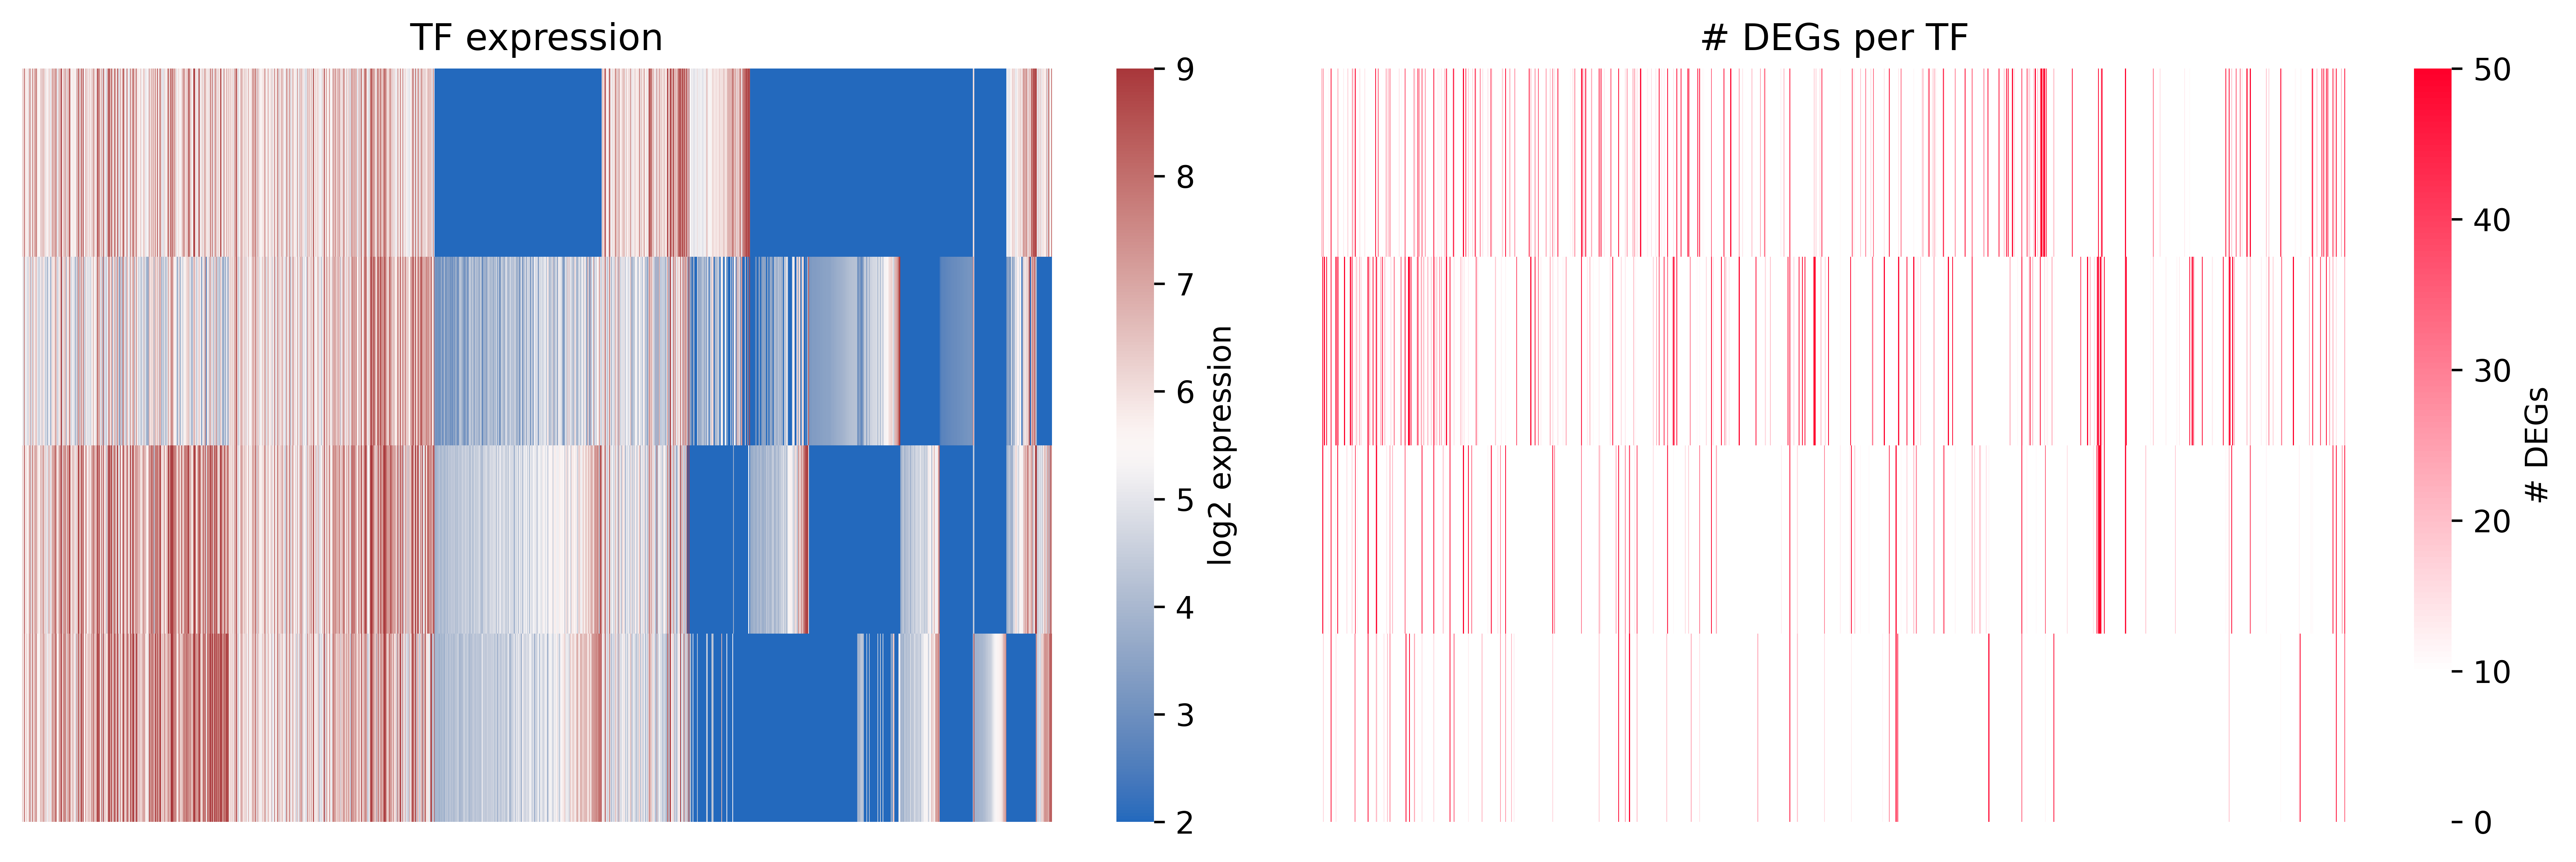

In [307]:
expr_mat = np.log2(TF_expr + pseudocount).loc[ordered_genes].T

deg_cnt = (
    topN_deg_count_long
    .pivot_table(
        index="dataset",
        columns="element_symbol",
        values="n_DEG",
        aggfunc="max",
        fill_value=0,
    )
    .reindex(index=expr_mat.index, columns=expr_mat.columns, fill_value=0)
)

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 4),
    sharey=True,
    dpi=600
)

sns.heatmap(
    expr_mat,
    ax=axes[0],
    cmap="vlag",
    center=5.5,
    vmin=2,
    vmax=9,
    yticklabels=True,
    xticklabels=False,
    cbar_kws={"label": "log2 expression"},
)

sns.heatmap(
    deg_cnt,
    robust=True,
    ax=axes[1],
    cmap=cmap,
    vmax=50,
    center=0,
    yticklabels=False,
    xticklabels=False,
    cbar_kws={"label": "# DEGs"},
)

axes[0].set_title("TF expression")
axes[1].set_title("# DEGs per TF")

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

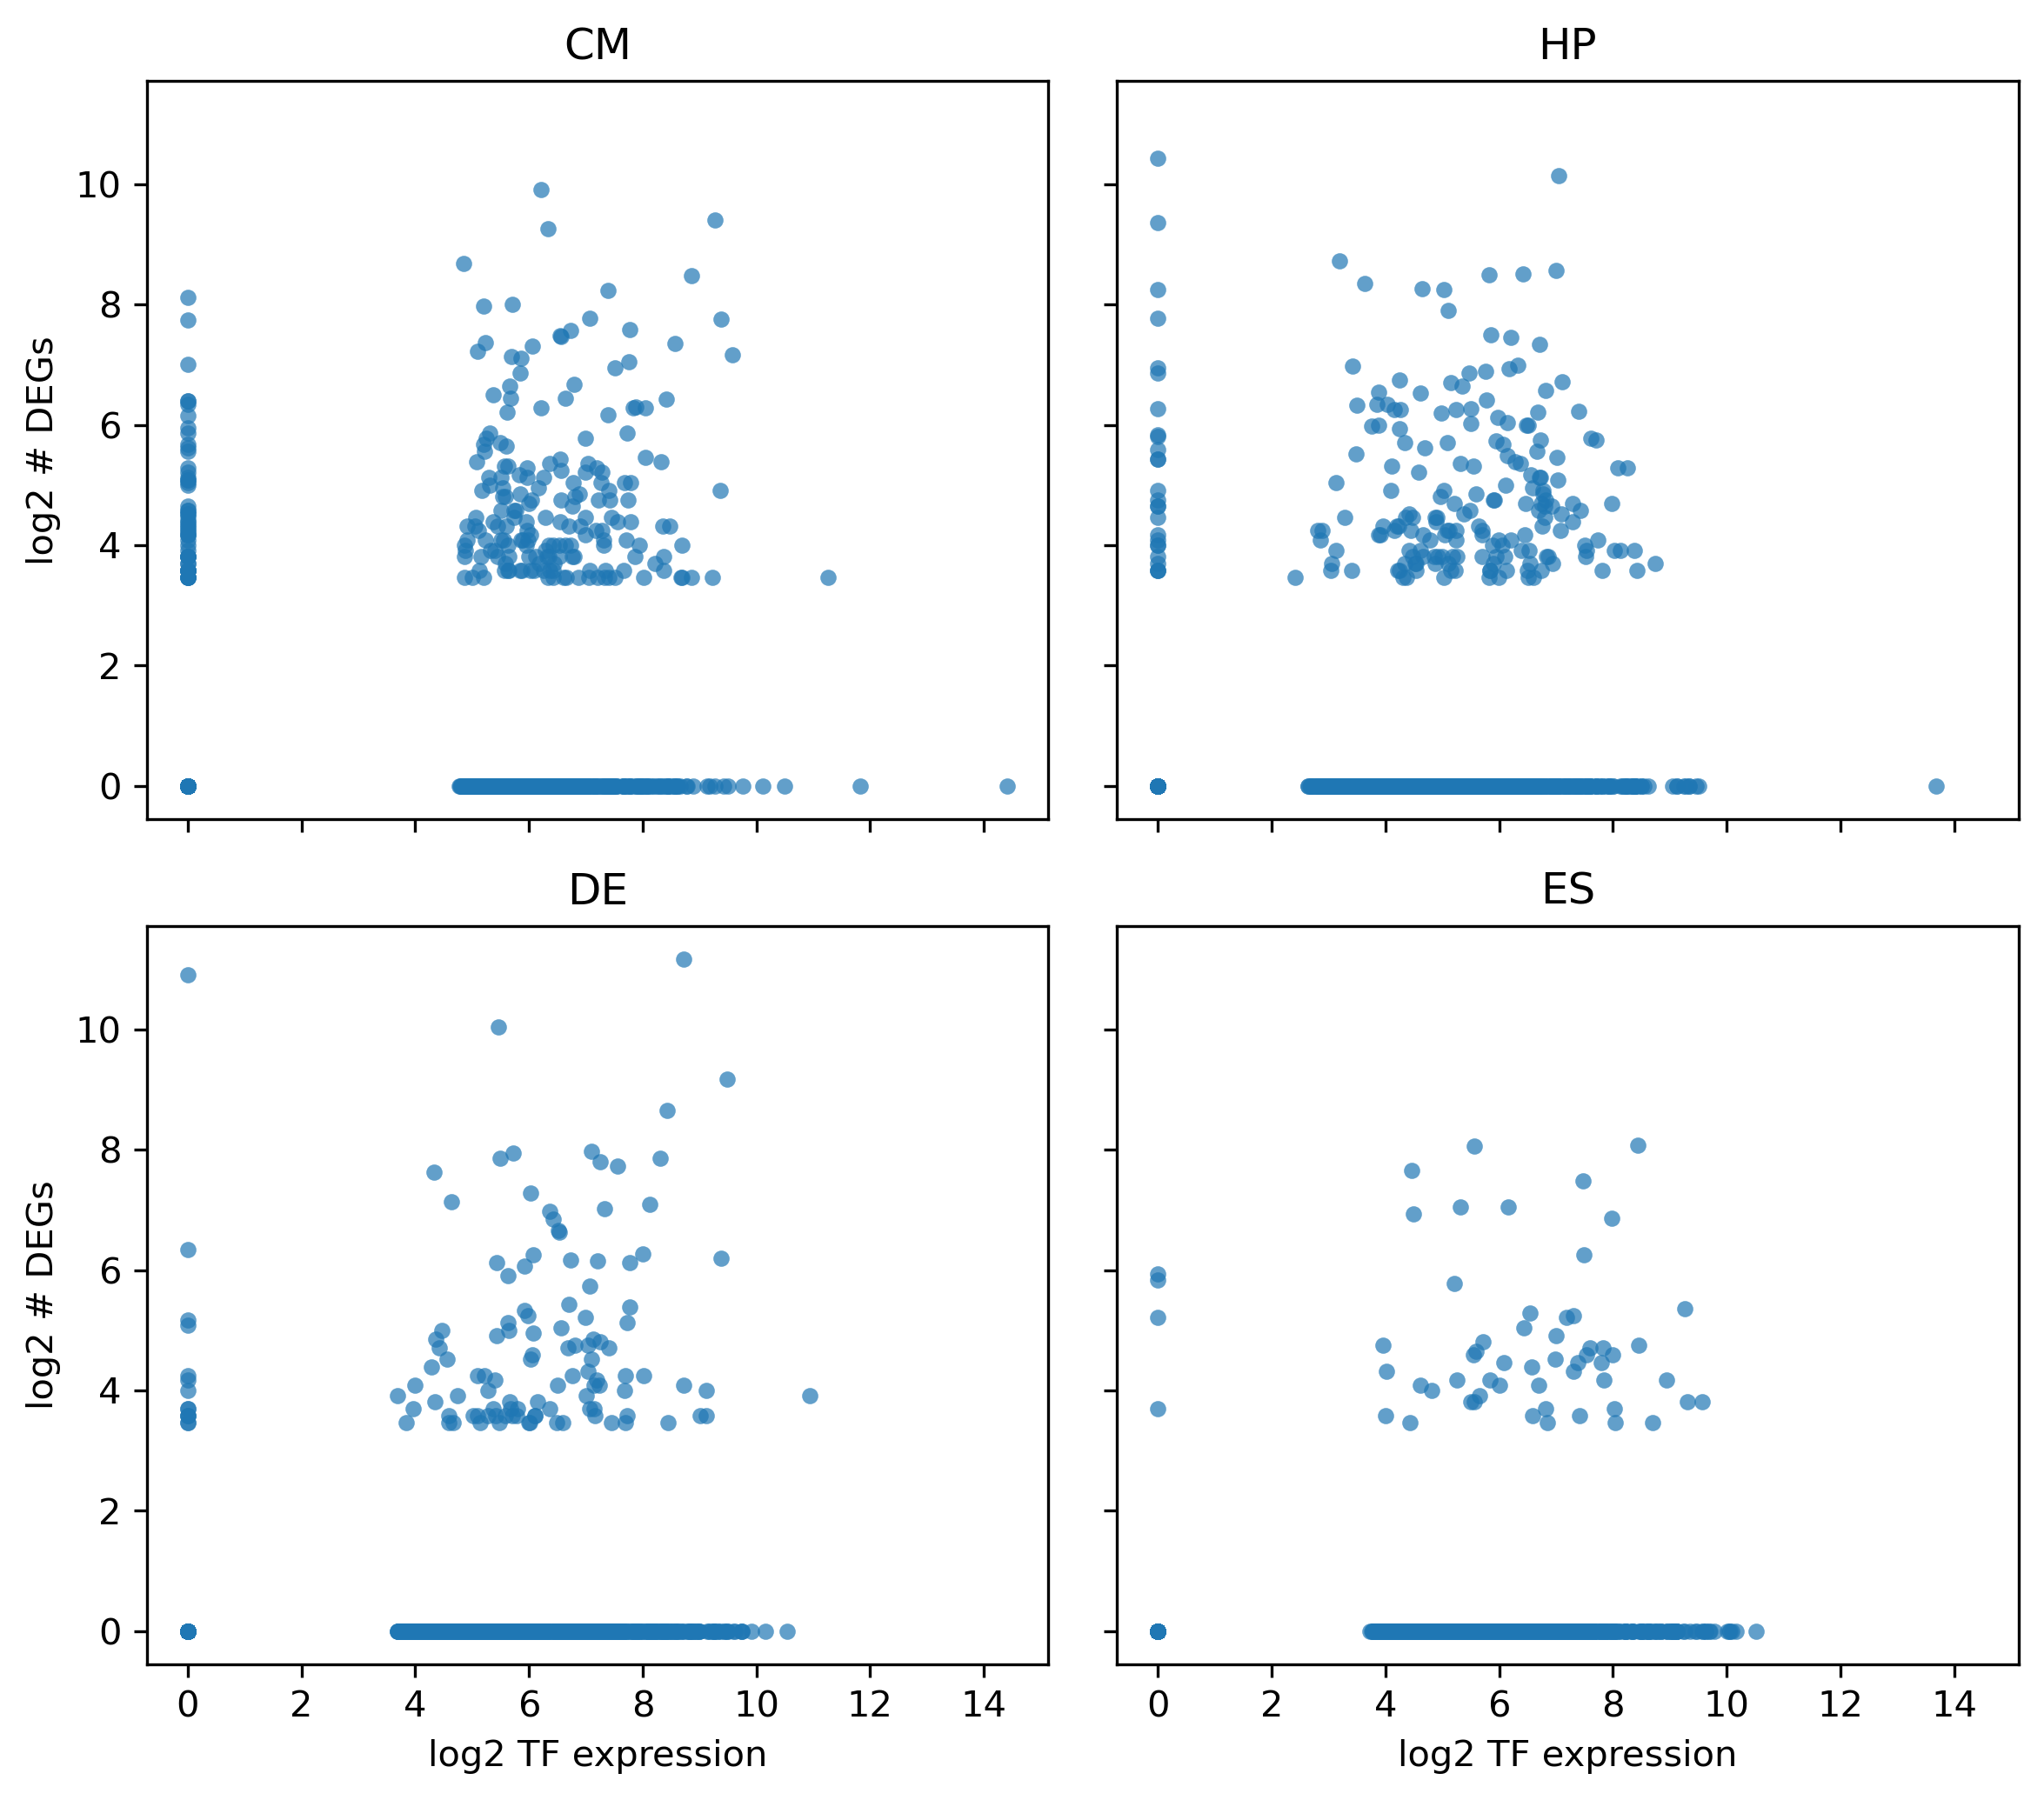

In [308]:
expr_mat = np.log2(TF_expr + pseudocount).loc[ordered_genes].T

deg_cnt = (
    topN_deg_count_long
    .pivot_table(
        index="dataset",
        columns="element_symbol",
        values="n_DEG",
        aggfunc="max",
        fill_value=0,
    )
    .reindex(index=expr_mat.index, columns=expr_mat.columns, fill_value=0)
)

datasets = expr_mat.index[:4]

fig, axes = plt.subplots(2, 2, figsize=(8, 7), sharex=True, sharey=True, dpi=300)

for ax, ds in zip(axes.flat, datasets):
    x = expr_mat.loc[ds]
    y = np.log2(deg_cnt.loc[ds] + 1)

    sns.scatterplot(
        x=x,
        y=y,
        ax=ax,
        s=20,
        lw=0,
        alpha=0.7,
    )

    ax.set_title(ds)
    ax.set_xlabel("log2 TF expression")
    ax.set_ylabel("log2 # DEGs")

plt.tight_layout()
plt.show()

In [309]:
for ax, ds in zip(axes.flat, datasets):
    x = expr_mat.loc[ds]
    y = deg_cnt.loc[ds]

    print(ds)
    # print(y[x==0].sort_values().tail(30))
    print(y[(x==0) & (y != 0)].shape)

CM
(56,)
HP
(26,)
DE
(14,)
ES
(4,)


In [310]:
for ax, ds in zip(axes.flat, datasets):
    x = expr_mat.loc[ds]
    y = deg_cnt.loc[ds]

    print(ds)
    print(y[(x==0) & (y != 0)].sort_values(ascending=False).head(30))

CM
TADA2B     277
FOXD3      214
ZSCAN10    127
MIXL1       83
LZTR1       83
ZC3H3       80
FOXC1       70
SIRT6       61
ADNP2       57
EOMES       50
ZNF384      48
MTF1        46
ZIC2        38
TAF5L       36
THAP5       34
MBD6        33
TAF4        33
ZFP64       32
LIN54       31
TCF7        24
TBX1        23
BRPF1       23
PRDM15      22
ZNF845      22
ZIC3        21
FOXA2       20
CDK2        20
WIZ         19
ETS1        19
SREBF1      18
Name: CM, dtype: int64
HP
FOXH1      1388
SOX17       655
MIXL1       302
GSC         218
YBX2        122
ZSCAN10     115
E2F1         76
TBX18        56
GBX2         55
TAF4B        47
ZNF138       42
ONECUT2      42
TCF19        29
ZNF783       26
SOX11        24
SALL3        24
ZEB2         21
EOMES        17
NMI          16
RCOR2        15
NKX2-5       15
ZNF74        13
ZNF273       12
IRX3         11
TIGD5        11
ZIC5         11
Name: HP, dtype: int64
DE
FOXH1     1923
SIRT6       80
CD151       35
LZTR1       33
ZNF649      18
FOXO

In [179]:
# Filter by a single p-value is 

element_symbol,FOXH1,TP53,SMAD3,CGGBP1,SOX17,DNMT1,RB1,SOX4,SMAD2,SOX11,...,RPA3,MYBL2,HINFP,BRIP1,OR56A4,RORB,AARS,CENPT,ERCC2,TAF1A
CM,21,153,28,16,4,0,200,426,59,845,...,0,1,0,0,0,0,0,0,0,0
HP,7143,7835,5710,5559,3108,4717,4421,4061,4496,2915,...,0,0,0,1,1,1,0,0,0,0
DE,1567,3,133,8,1871,96,0,115,1,142,...,0,0,0,0,0,0,0,0,0,0
ES,21,2,3,2,0,49,1,10,0,18,...,1,0,1,0,0,0,1,1,1,1
total,8752,7993,5874,5585,4983,4862,4622,4612,4556,3920,...,1,1,1,1,1,1,1,1,1,1


In [177]:
g.data2d.columns

Index(['SNAPC3', 'ZBED5', 'KDM5B', 'DPF2', 'VEZF1', 'GTF3C3', 'SMAD7',
       'ZNF334', 'TFAM', 'TCERG1',
       ...
       'GLI3', 'ETV5', 'GLI2', 'CDCA7L', 'SOX11', 'ETV1', 'ZNF521', 'LDB2',
       'JAZF1', 'RUNX1T1'],
      dtype='object', length=1221)

In [183]:
TF_found = [n for n in g.data2d.columns if n in DEG_sig_count_all.index]

<Axes: xlabel='element_symbol'>

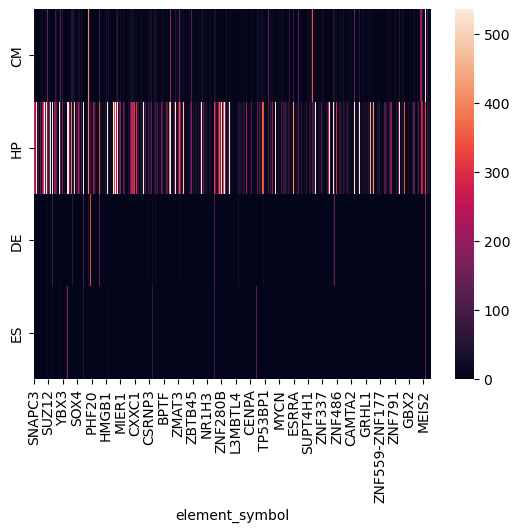

In [184]:
sns.heatmap(
    DEG_sig_count_all.T.loc[g.data2d.index, TF_found], robust=True
)

In [182]:
np.log2(TF_expr+1).loc[['RPF1', 'MNAT1', 'MYBBP1A', 'SUPT5H', 'ORAI1', 'NOC3L', 'GTF2B', 'CHMP2A', 'ZNF511', 'ATF5', 'NANOG']]

,CM,HP,DE,ES
RPF1,5.159032,4.389867,5.858382,5.525314
MNAT1,6.511562,5.949655,6.994948,7.523162
MYBBP1A,4.772163,4.140413,4.202959,5.695586
SUPT5H,6.416844,6.658015,6.691709,6.589335
ORAI1,5.574965,4.886710,5.649630,5.366522
NOC3L,5.281253,5.139275,5.530817,6.129262
GTF2B,6.071010,5.155467,5.376923,5.169451
CHMP2A,8.009662,6.671797,6.465621,6.584203
ZNF511,5.033852,4.266114,0.000000,0.000000
ATF5,0.000000,3.324506,0.000000,0.000000


In [114]:
cluster_tf = (
    adata.obs
    .reset_index(names="TF")
    .groupby("leiden_expr")
    .TF
    .apply(list)
)

cluster_tf

/users/yyang117/tmp/ipykernel_1368170/40437652.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("leiden_expr")


leiden_expr
0     [TARDBP, PRDM2, SCMH1, FOXJ3, YBX1, MIER1, ZNF...
1     [SH3D19, ZBTB17, ZBTB40, LIN28A, GMEB1, ZNF362...
2     [SKI, RERE, SPEN, ARID1A, TAF12, GPBP1L1, MYSM...
3     [CAMTA1, HMGN2, HDAC1, RLF, NFYC, NFIA, LMO4, ...
4     [ENO1, ID3, ZNF593, AHDC1, MED8, DMAP1, GTF2B,...
5     [RXRG, AFF3, ZEB2, TADA3, NFKBIZ, LEF1, HAND2,...
6     [HES4, PROX1, SMYD2, ESRRG, MEIS1, RARB, MITF,...
7     [TAF1A, SIX3, ZNF732, IRX2, FOXC1, ZNF107, ZNF...
8     [THAP3, CASZ1, JUN, MEF2D, ATF3, ZNF692, SOX11...
9     [MAEL, EPAS1, THRB, ZIC1, NR3C2, ZNF804B, CREB...
10    [STAT4, CXXC4, PRDM1, FOXP2, GLIS3, ZNF740, TB...
Name: TF, dtype: object

In [125]:
cluster_tf.loc['10']

['STAT4',
 'CXXC4',
 'PRDM1',
 'FOXP2',
 'GLIS3',
 'ZNF740',
 'TBX3',
 'KLF5',
 'FOXA1',
 'OTX2',
 'ARNT2',
 'HNF1B',
 'ZNF888',
 'FOXA2',
 'ZHX3',
 'HNF4A',
 'ZNF512B',
 'KLF8',
 'GLIS1',
 'MIXL1',
 'EOMES',
 'FOXQ1',
 'MNX1',
 'SOX17',
 'HHEX',
 'PAX2',
 'PAX6',
 'GSC',
 'LHX1']

In [133]:
adata[['SOX17', 'GATA6', 'EOMES', 'SMAD2', 'SMAD3']].obs

,mean_expr,min_expr,log2fc_sd,max_abs_log2fc,leiden_expr
SOX17,104.691322,0.000000,4.356719,6.723713,10
GATA6,138.187790,0.000000,3.759793,7.120889,6
EOMES,64.462433,0.000000,4.007986,6.032595,10
SMAD2,257.779846,127.188393,0.742687,1.013460,2
SMAD3,87.992096,44.266670,0.815006,0.975228,3


#### GO Analysis of the Cluster of TF by Expression Clustering

In [ ]:
msig = gp.Msigdb()
msig.list_category(dbver="2024.1.Hs") 

gmt1 = msig.get_gmt(category='c2.all', dbver="2024.1.Hs")
gmt2 = msig.get_gmt(category='c5.all', dbver="2024.1.Hs")
gmt3 = msig.get_gmt(category='h.all', dbver="2024.1.Hs")

print(len(gmt1), len(gmt2), len(gmt3))

allgmt = {**gmt1, **gmt2, **gmt3}
print(len(allgmt))

gmtsmall = dict([(k,v) for k,v in allgmt.items() if len(v) < 1000 and len(v) > 5])
print(len(gmtsmall))

In [107]:
enrg = gp.enrich(gene_list=cluster_tf.loc['10'],
                 gene_sets=[gmt1, gmt2, gmt3],
                 background=20_000,
                 outdir=None,
                 verbose=True)
display(enrg.results.sort_values('Adjusted P-value').head(30).iloc[:,1:])

2026-05-15 12:10:40,560 [INFO] Input dict object named with gs_ind_0
2026-05-15 12:10:40,561 [INFO] Input dict object named with gs_ind_1
2026-05-15 12:10:40,561 [INFO] Input dict object named with gs_ind_2
2026-05-15 12:10:40,561 [INFO] Run: gs_ind_0 
2026-05-15 12:10:40,773 [INFO] Run: gs_ind_1 
2026-05-15 12:10:41,141 [INFO] Run: gs_ind_2 
2026-05-15 12:10:41,146 [INFO] Done.


,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
1219,GOMF_TRANSCRIPTION_REGULATOR_ACTIVITY,31/1963,5.099992e-24,6.400490e-21,30.933356,1659.042599,ZNF552;ZKSCAN2;MYT1L;SRCAP;ZNF707;ZNF655;ZFP69...
1182,GOMF_DNA_BINDING_TRANSCRIPTION_FACTOR_ACTIVITY,28/1463,2.923197e-23,1.834306e-20,29.423992,1526.716157,ZNF552;ZKSCAN2;MYT1L;ZNF707;ZNF655;ZFP69;ZNF32...
1215,GOMF_SEQUENCE_SPECIFIC_DNA_BINDING,24/1675,2.041929e-16,8.542068e-14,16.461903,594.726865,ZNF552;ZKSCAN2;ZNF707;ZNF655;ZFP69;ZNF32;ZNF50...
1178,GOMF_CIS_REGULATORY_REGION_SEQUENCE_SPECIFIC_D...,20/1220,1.866318e-14,5.855571e-12,15.627239,494.011769,ZNF552;ZKSCAN2;ZNF707;ZNF655;ZNF32;ZNF500;ZNF6...
529,REACTOME_RNA_POLYMERASE_II_TRANSCRIPTION,14/1387,2.334010e-07,1.724833e-04,7.404819,113.075347,ZNF552;NR2F1;ZNF461;ZNF500;ZNF211;ZNF791;ZNF50...
1183,GOMF_DNA_BINDING_TRANSCRIPTION_REPRESSOR_ACTIVITY,6/273,1.591583e-05,3.994873e-03,13.870540,153.244454,NR2F1;ERF;ZBTB14;MYT1L;MAFK;PATZ1
1214,GOMF_RETINOIC_ACID_RESPONSIVE_ELEMENT_BINDING,2/6,5.820710e-05,1.217498e-02,287.972583,2808.165583,NR2F1;RXRB
921,GOBP_NEGATIVE_REGULATION_OF_TRANSCRIPTION_BY_R...,9/923,6.856513e-05,1.229275e-02,6.281227,60.222691,NR2F1;ERF;THAP5;ZBTB14;SP100;MYT1L;CDK2;MAFK;P...
917,GOBP_NEGATIVE_REGULATION_OF_RNA_BIOSYNTHETIC_P...,10/1282,1.629521e-04,2.556311e-02,5.055989,44.098611,NR2F1;ERF;THAP5;ZBTB14;PFDN5;SP100;MYT1L;CDK2;...
309,LEE_AGING_MUSCLE_DN,3/40,6.955803e-05,2.570169e-02,49.587378,474.717286,DBP;NR2F1;ZNF32


In [316]:
CM_gene_var.shape

(7260, 13)

In [317]:
HP_gene_var.shape

(11138, 13)

In [318]:
DE_gene_var.shape

(9584, 13)

In [319]:
ES_gene_var.shape

(9519, 13)

In [312]:
CM_gene_var[CM_gene_var.symbol.eq('ATF5')]

,symbol,mt,ribo,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_cells,gene_chr,gene_start,gene_end
gene_id,,,,,,,,,,,,,


In [313]:
HP_gene_var[HP_gene_var.symbol.eq('ATF5')]

,symbol,mt,ribo,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_cells,gene_chr,gene_start,gene_end
gene_id,,,,,,,,,,,,,
ENSG00000169136,ATF5,False,False,196932,0.002066,0.002064,99.805248,208940.0,12.249807,100314,chr19,49928702.0,49933935.0


In [314]:
DE_gene_var[DE_gene_var.symbol.eq('ATF5')]

,symbol,mt,ribo,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_cells,gene_chr,gene_start,gene_end
gene_id,,,,,,,,,,,,,


In [315]:
ES_gene_var[ES_gene_var.symbol.eq('ATF5')]

,symbol,mt,ribo,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_cells,gene_chr,gene_start,gene_end
gene_id,,,,,,,,,,,,,
